In [1]:
import sys

sys.path.append("../")

import json

import numpy as np

from qiskit.transpiler import generate_preset_pass_manager
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit_ibm_runtime import QiskitRuntimeService, EstimatorV2 as Estimator, SamplerV2 as Sampler

from dicke_state_ansatz import DickeStateAnsatz

In [2]:
simulator = AerSimulator(method="statevector")

In [3]:
with open(file="../../secrets/credentials.json", mode="rt") as f:
    credentials = json.load(f)

In [4]:
service = QiskitRuntimeService(**credentials)

qiskit_runtime_service._discover_account:WARNING:2026-05-05 00:47:13,373: Loading account with the given token. A saved account will not be used.


In [5]:
n = 7
k = 4
qc = DickeStateAnsatz().generate_quantum_circuit(n=n, k=k)

In [6]:
params_mapping = {param: np.pi/2 for param in qc.parameters}
qc = qc.assign_parameters(parameters=params_mapping)

In [7]:
counts = simulator.run(circuits=qc, shots=4096).result().get_counts()

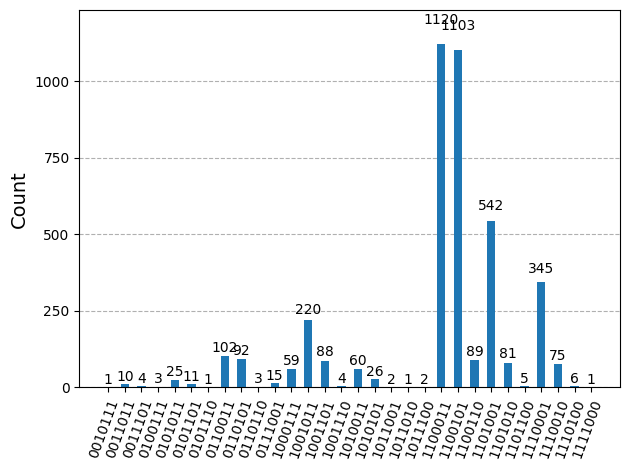

In [8]:
plot_histogram(data=counts)

In [9]:
backend = service.backend(name="ibm_kingston")
pm = generate_preset_pass_manager(backend=backend, optimization_level=2)

In [10]:
n = 7
k = 4
qc = DickeStateAnsatz().generate_quantum_circuit(n=n, k=k)

In [11]:
params_mapping = {param: np.pi/2 for param in qc.parameters}
qc = qc.assign_parameters(parameters=params_mapping)

In [12]:
sampler = Sampler(mode=backend)

In [13]:
tqc = pm.run(qc)

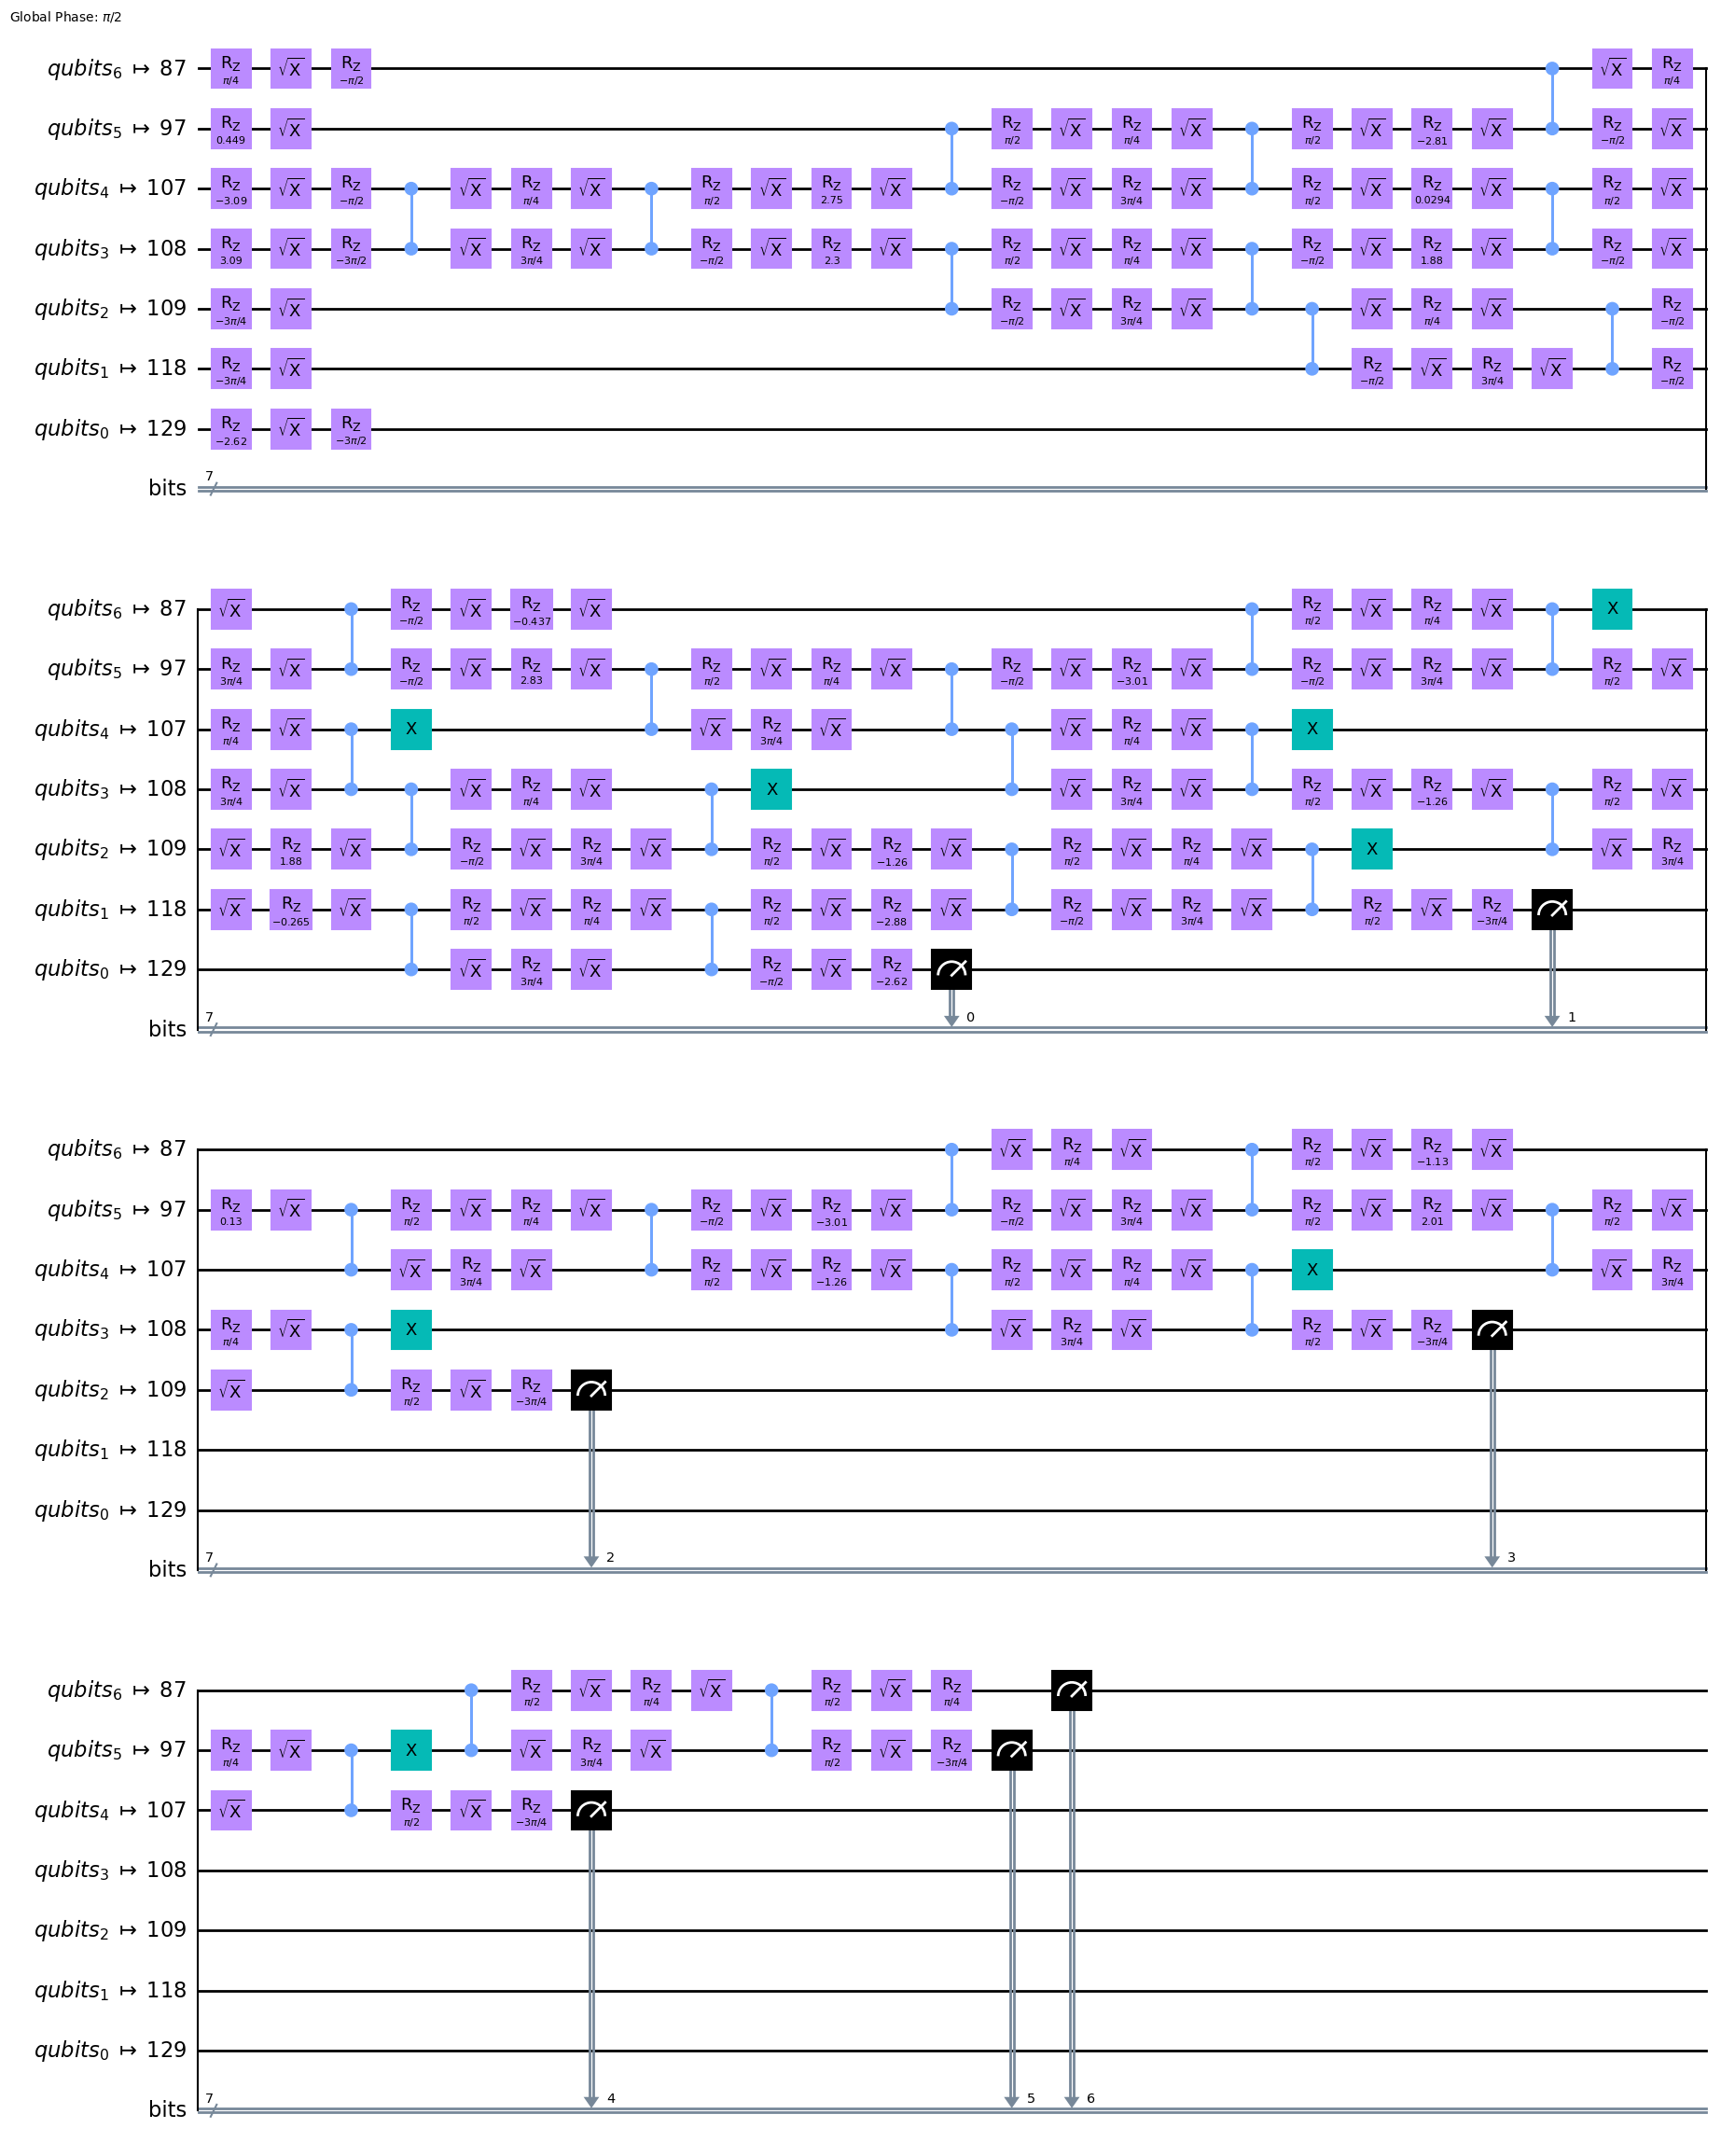

In [14]:
tqc.draw(output="mpl", style="clifford")

In [15]:
sampler_job = sampler.run(pubs=[(tqc,)], shots=4096)

In [16]:
sampler_job.job_id()

'd7smh27ljm6s73bbllug'

In [17]:
sampler_job.status()

'RUNNING'

In [18]:
sampler_result = sampler_job.result()
# sampler_result = service.job(job_id="d7smh27ljm6s73bbllug")

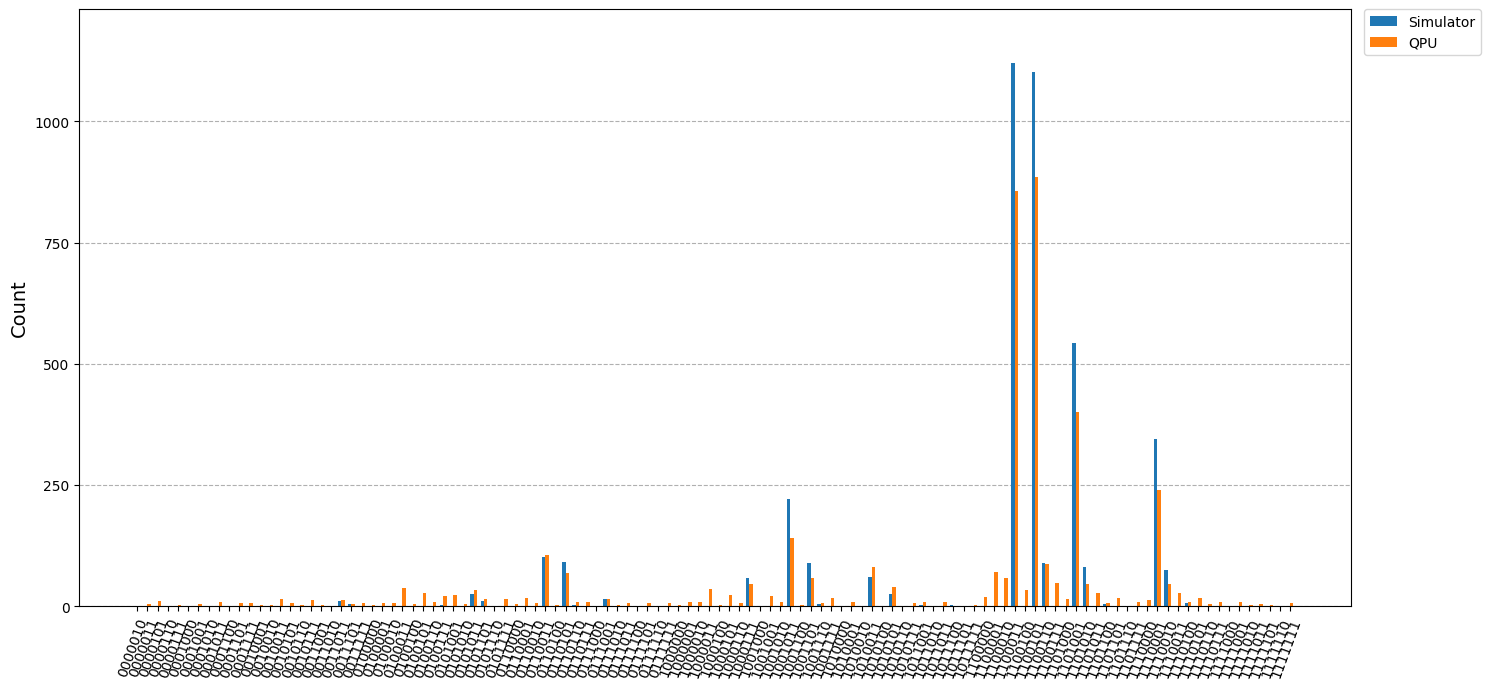

In [25]:
plot_histogram(
    data=[
        counts, 
        sampler_result[0].data.bits.get_counts()
    ],
    figsize=(15,7),
    legend=["Simulator", "QPU"],
    bar_labels=False
)